Data Source: https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data/data?select=salesdaily.csv

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Load the daily dataset
print("Loading daily sales data...")
df = pd.read_csv('data/salesdaily.csv')

# Convert 'datum' to datetime format and set it as the index
df['datum'] = pd.to_datetime(df['datum'])
df.set_index('datum', inplace=True)

print("Data loaded successfully. Here are the first 3 rows:")
display(df.head(3))

Loading daily sales data...
Data loaded successfully. Here are the first 3 rows:


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
datum,,,,,,,,,,,,
2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2106 entries, 2014-01-02 to 2019-10-08
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   M01AB         2106 non-null   float64
 1   M01AE         2106 non-null   float64
 2   N02BA         2106 non-null   float64
 3   N02BE         2106 non-null   float64
 4   N05B          2106 non-null   float64
 5   N05C          2106 non-null   float64
 6   R03           2106 non-null   float64
 7   R06           2106 non-null   float64
 8   Year          2106 non-null   int64  
 9   Month         2106 non-null   int64  
 10  Hour          2106 non-null   int64  
 11  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(1)
memory usage: 213.9+ KB


In [ ]:
# The 8 specific drug categories in the dataset
drug_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Isolate all target categories
drugs_daily = df[drug_columns].copy()

# Resample the daily data into Weekly totals
print("Aggregating daily data into weekly totals for all categories...")
weekly_data = drugs_daily.resample('W').sum()

print("Master roll-up complete. Weekly data shape:", weekly_data.shape)
display(weekly_data.head(3))

Aggregating daily data into weekly totals for all categories...
Master roll-up complete. Weekly data shape: (302, 8)


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
datum,,,,,,,,
2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0


In [24]:
category_labels = {
    'M01AB': 'Anti-inflammatories (Acetic Acid)',
    'M01AE': 'Anti-inflammatories (Ibuprofen/Propionic)',
    'N02BA': 'Painkillers (Aspirin)',
    'N02BE': 'Painkillers (Acetaminophen)',
    'N05B': 'Anti-anxiety Medications',
    'N05C': 'Sleep Aids / Sedatives',
    'R03': 'Asthma / Airway Medications',
    'R06': 'Allergy Medications (Antihistamines)'
}

In [25]:
weekly_data.rename(columns=category_labels, inplace=True)

Generating exploratory visualization for all categories...


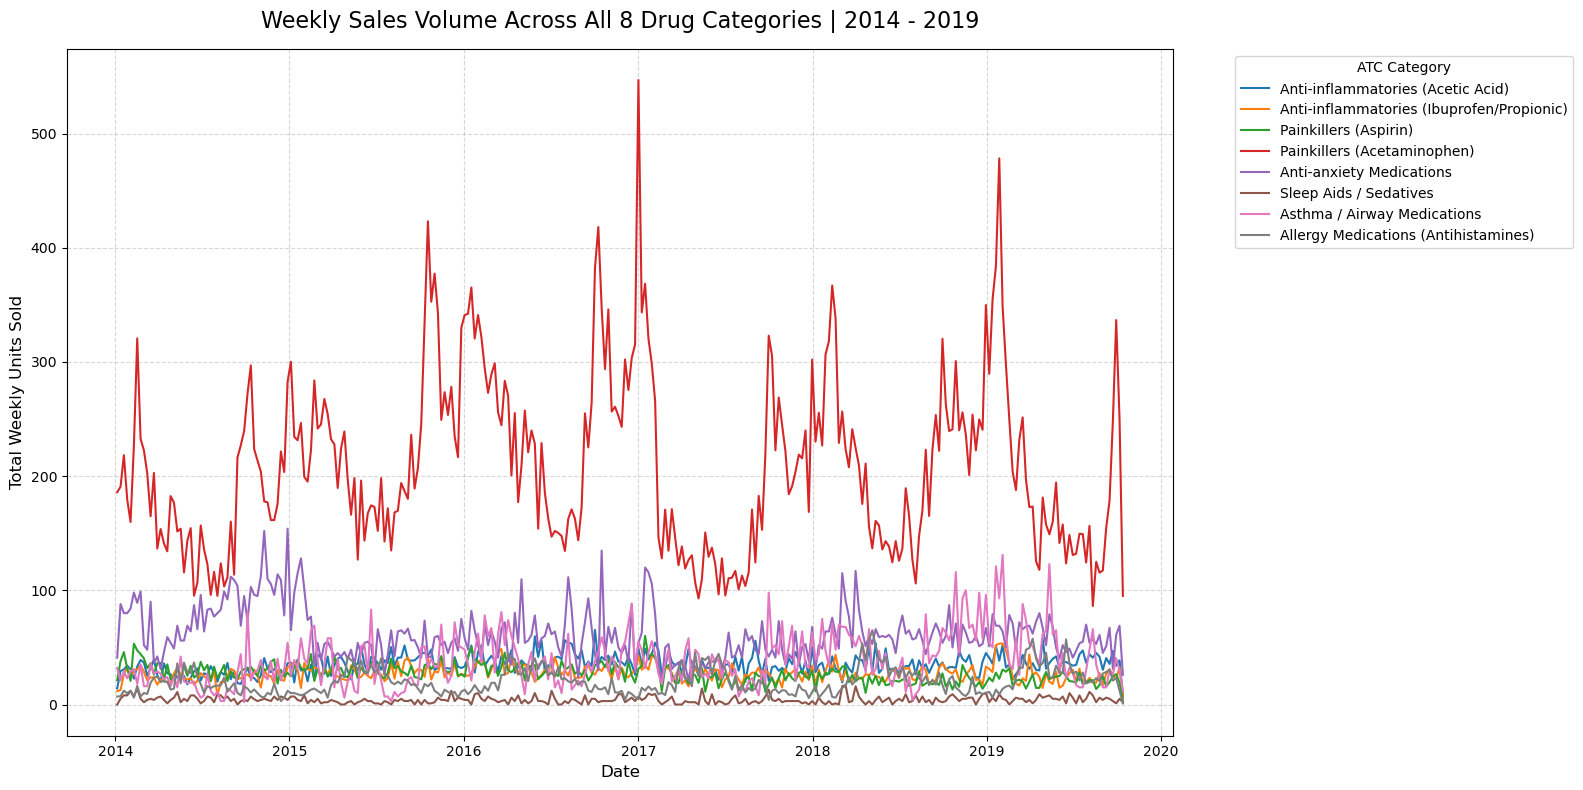

In [26]:
print("Generating exploratory visualization for all categories...")
plt.figure(figsize=(16, 8))

# Loop through all 8 columns and plot them on the same chart
for column in weekly_data.columns:
    plt.plot(weekly_data.index, weekly_data[column], label=column, linewidth=1.5)

# Formatting
plt.title('Weekly Sales Volume Across All 8 Drug Categories | 2014 - 2019', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Weekly Units Sold', fontsize=12)

# Place the legend outside the plot area so it doesn't cover the data
plt.legend(title='ATC Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot
plt.savefig('all_drugs_weekly_trends.png')
plt.show()

# Forecasting with Supervised Learning
Using Random Forest Regression to predict future sales based on historical data


In [ ]:
print("Evaluating predictability for all 8 categories...")

# List of all categories
drug_columns = category_labels.values()
r2_scores = {}

# Loop through each drug category
for drug in drug_columns:
    # Isolate the target and create time features
    temp_data = weekly_data[[drug]].copy()
    temp_data['Month'] = temp_data.index.month
    temp_data['Year'] = temp_data.index.year
    
    # Define Features (X) and Target (y)
    X = temp_data[['Month', 'Year']]
    y = temp_data[drug]
    
    # Train/Test Split (Sequential)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    
    # Train the model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Calculate and store the R^2 score
    score = model.score(X_test, y_test)
    r2_scores[drug] = round(score, 3)

# Sort the dictionary by highest R^2 score
sorted_scores = dict(sorted(r2_scores.items(), key=lambda item: item[1], reverse=True))

print("-" * 40)
print("Model R² Scores (Highest to Lowest):")
for drug, score in sorted_scores.items():
    print(f"{drug}: {score}")
print("-" * 40)

Evaluating predictability for all 8 categories...
----------------------------------------
Model R² Scores (Highest to Lowest):
Allergy Medications (Antihistamines): 0.346
Painkillers (Acetaminophen): 0.287
Anti-inflammatories (Ibuprofen/Propionic): 0.018
Anti-inflammatories (Acetic Acid): -0.123
Asthma / Airway Medications: -0.222
Anti-anxiety Medications: -0.277
Painkillers (Aspirin): -0.469
Sleep Aids / Sedatives: -0.52
----------------------------------------


In [28]:
# Find max date of the original data
last_date = ml_data.index.max()
print(f"Last date in original data: {last_date.strftime('%Y-%m-%d')}")

Last date in original data: 2019-10-13


Preparing data and retraining model for Allergy Medications (Antihistamines)...
Generating 12-month forecast...


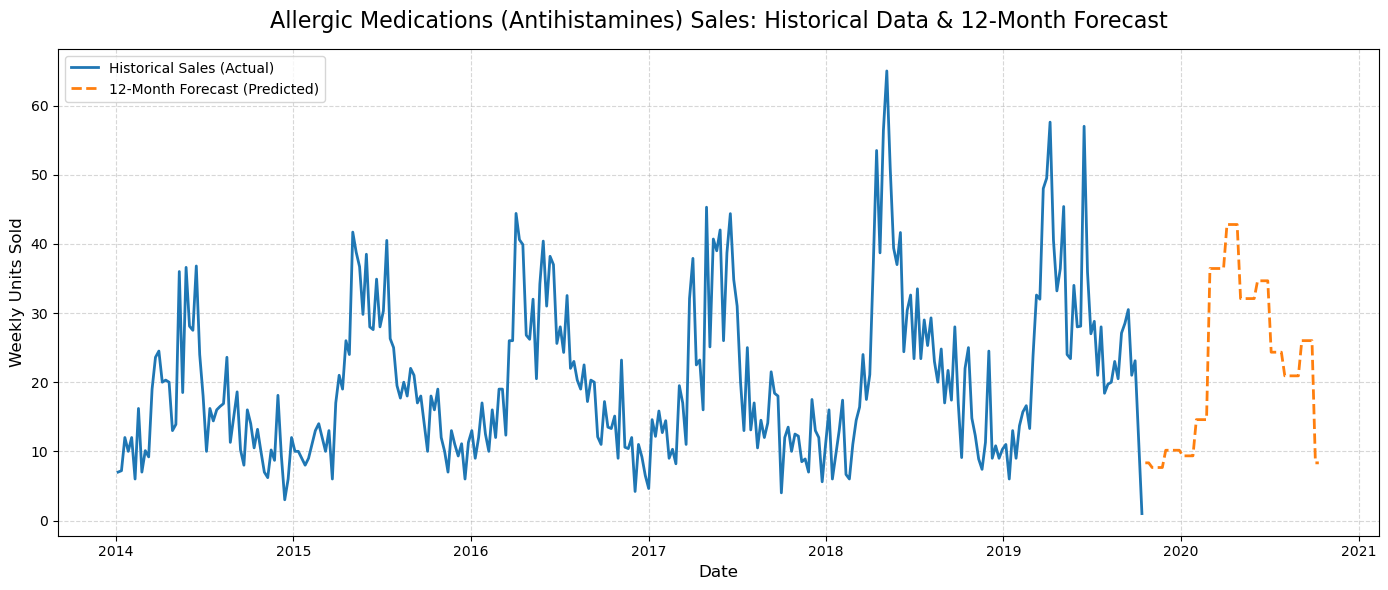

--------------------------------------------------
🎯 12-MONTH FORECAST COMPLETE
The model predicts demand will peak the week of 2020-04-05
with an estimated 43 units sold.
--------------------------------------------------


In [ ]:
print("Preparing data and retraining model for Allergy Medications (Antihistamines)...")

# Isolate Allergy Medications (Antihistamines) from the master weekly data and set up features
ml_data = weekly_data[['Allergy Medications (Antihistamines)']].copy()
ml_data['Month'] = ml_data.index.month
ml_data['Year'] = ml_data.index.year

# Define Features and Target, then retrain the model
X = ml_data[['Month', 'Year']]
y = ml_data['Allergy Medications (Antihistamines)']
model.fit(X, y)

# 12-Month Future Forecast & Visualization
print("Generating 12-month forecast...")

# Find the exact last date in our historical data
last_date = ml_data.index.max()

# Create a list of weekly dates for the next 52 weeks (approx 1 year)
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=52, freq='W')

# Create a new DataFrame for these future dates
future_df = pd.DataFrame(index=future_dates)
future_df['Month'] = future_df.index.month
future_df['Year'] = future_df.index.year

# Make the predictions for the entire year
future_predictions = model.predict(future_df[['Month', 'Year']])
future_df['Predicted_Allergy Medications (Antihistamines)'] = future_predictions

# Visualize Historical + Future Predictions
plt.figure(figsize=(14, 6))

# Plot historical data (solid blue line)
plt.plot(ml_data.index, ml_data['Allergy Medications (Antihistamines)'], label='Historical Sales (Actual)', color='#1f77b4', linewidth=2)

# Plot future predictions (dashed orange line)
plt.plot(future_df.index, future_df['Predicted_Allergy Medications (Antihistamines)'], label='12-Month Forecast (Predicted)', color='#ff7f0e', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('Allergic Medications (Antihistamines) Sales: Historical Data & 12-Month Forecast', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Units Sold', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the chart so you can drop it into your README
plt.savefig('r06_12_month_forecast.png')
plt.show()

# Print a quick summary text block to use for your AI prompt
peak_week = future_df['Predicted_Allergy Medications (Antihistamines)'].idxmax()
peak_volume = future_df['Predicted_Allergy Medications (Antihistamines)'].max()
print("-" * 50)
print("🎯 12-MONTH FORECAST COMPLETE")
print(f"The model predicts demand will peak the week of {peak_week.strftime('%Y-%m-%d')}")
print(f"with an estimated {peak_volume:.0f} units sold.")
print("-" * 50)

Preparing data and retraining model for Painkillers (Acetaminophen)'...
Generating 12-month forecast for Painkillers (Acetaminophen)...


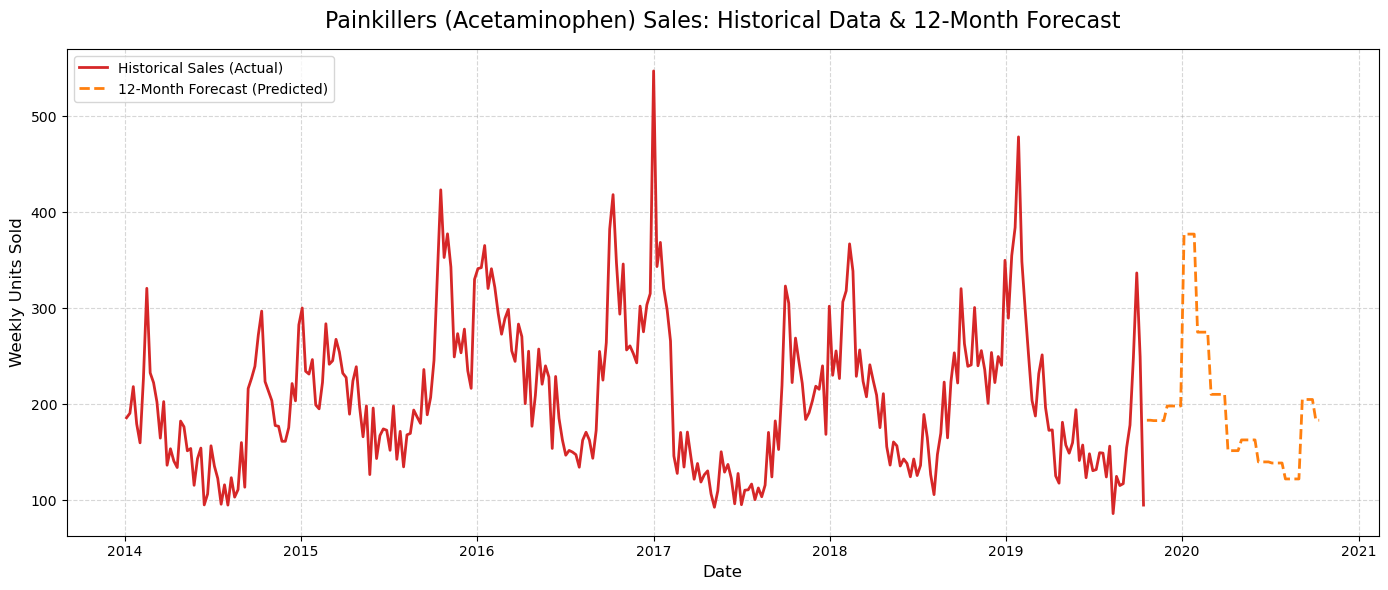

--------------------------------------------------
🎯 Painkillers (Acetaminophen) 12-MONTH FORECAST COMPLETE
The model predicts demand will peak the week of 2020-01-05
with an estimated 377 units sold.
--------------------------------------------------


In [ ]:
print("Preparing data and retraining model for Painkillers (Acetaminophen)'...")

# Isolate Painkillers (Acetaminophen) from the master weekly data and set up features
ml_data = weekly_data[['Painkillers (Acetaminophen)']].copy()
ml_data['Month'] = ml_data.index.month
ml_data['Year'] = ml_data.index.year

# Define Features and Target, then retrain the model
X = ml_data[['Month', 'Year']]
y = ml_data['Painkillers (Acetaminophen)']
model.fit(X, y)

# Generate 12-month forecast dates
print("Generating 12-month forecast for Painkillers (Acetaminophen)...")
last_date = ml_data.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=52, freq='W')
future_df = pd.DataFrame(index=future_dates)
future_df['Month'] = future_df.index.month
future_df['Year'] = future_df.index.year

# Make the predictions
future_predictions = model.predict(future_df[['Month', 'Year']])
future_df['Predicted_Painkillers (Acetaminophen)'] = future_predictions

# Visualize Historical + Future Predictions
plt.figure(figsize=(14, 6))

# Plot historical data (using a red line to match your earlier master chart for N02BE)
plt.plot(ml_data.index, ml_data['Painkillers (Acetaminophen)'], label='Historical Sales (Actual)', color='#d62728', linewidth=2)

# Plot future predictions (dashed orange line)
plt.plot(future_df.index, future_df['Predicted_Painkillers (Acetaminophen)'], label='12-Month Forecast (Predicted)', color='#ff7f0e', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('Painkillers (Acetaminophen) Sales: Historical Data & 12-Month Forecast', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Units Sold', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the chart
plt.savefig('painkillers_acetaminophen_12_month_forecast.png')
plt.show()

# Print a quick summary text block
peak_week = future_df['Predicted_Painkillers (Acetaminophen)'].idxmax()
peak_volume = future_df['Predicted_Painkillers (Acetaminophen)'].max()
print("-" * 50)
print("🎯 Painkillers (Acetaminophen) 12-MONTH FORECAST COMPLETE")
print(f"The model predicts demand will peak the week of {peak_week.strftime('%Y-%m-%d')}")
print(f"with an estimated {peak_volume:.0f} units sold.")
print("-" * 50)

Preparing data and retraining model for Anti-inflammatories (Ibuprofen/Propionic) ...
Generating 12-month forecast for Anti-inflammatories (Ibuprofen/Propionic) ...


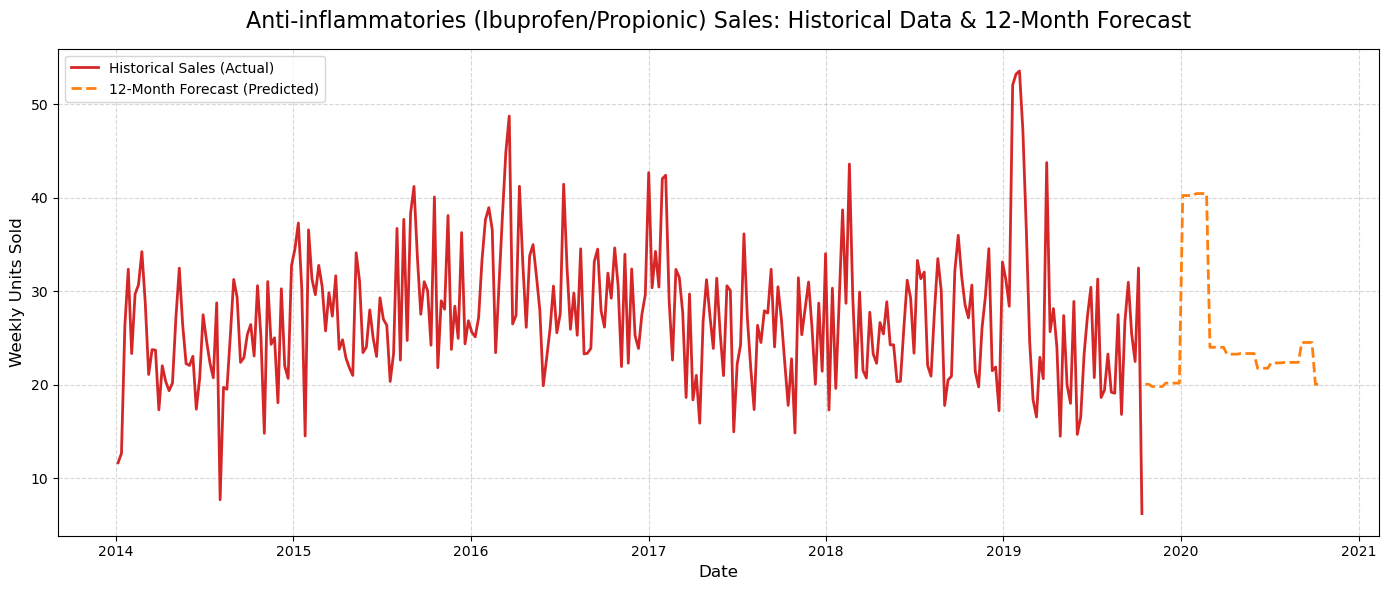

--------------------------------------------------
🎯 Anti-inflammatories (Ibuprofen/Propionic) 12-MONTH FORECAST COMPLETE
The model predicts demand will peak the week of 2020-02-02
with an estimated 40 units sold.
--------------------------------------------------


In [ ]:
print("Preparing data and retraining model for Anti-inflammatories (Ibuprofen/Propionic) ...")

# Isolate Anti-inflammatories (Ibuprofen/Propionic) from the master weekly data and set up features
ml_data = weekly_data[['Anti-inflammatories (Ibuprofen/Propionic)']].copy()
ml_data['Month'] = ml_data.index.month
ml_data['Year'] = ml_data.index.year

# Define Features and Target, then retrain the model
X = ml_data[['Month', 'Year']]
y = ml_data['Anti-inflammatories (Ibuprofen/Propionic)']
model.fit(X, y)

# Generate 12-month forecast dates
print("Generating 12-month forecast for Anti-inflammatories (Ibuprofen/Propionic) ...")
last_date = ml_data.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=52, freq='W')
future_df = pd.DataFrame(index=future_dates)
future_df['Month'] = future_df.index.month
future_df['Year'] = future_df.index.year

# Make the predictions
future_predictions = model.predict(future_df[['Month', 'Year']])
future_df['Predicted_Anti-inflammatories (Ibuprofen/Propionic)'] = future_predictions

# Visualize Historical + Future Predictions
plt.figure(figsize=(14, 6))

# Plot historical data (using a red line to match your earlier master chart for N02BE)
plt.plot(ml_data.index, ml_data['Anti-inflammatories (Ibuprofen/Propionic)'], label='Historical Sales (Actual)', color='#d62728', linewidth=2)

# Plot future predictions (dashed orange line)
plt.plot(future_df.index, future_df['Predicted_Anti-inflammatories (Ibuprofen/Propionic)'], label='12-Month Forecast (Predicted)', color='#ff7f0e', linewidth=2, linestyle='--')

# Formatting the chart
plt.title('Anti-inflammatories (Ibuprofen/Propionic) Sales: Historical Data & 12-Month Forecast', fontsize=16, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Units Sold', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the chart
plt.savefig('anti_inflammatories_12_month_forecast.png')
plt.show()

# Print a quick summary text block
peak_week = future_df['Predicted_Anti-inflammatories (Ibuprofen/Propionic)'].idxmax()
peak_volume = future_df['Predicted_Anti-inflammatories (Ibuprofen/Propionic)'].max()
print("-" * 50)
print("🎯 Anti-inflammatories (Ibuprofen/Propionic) 12-MONTH FORECAST COMPLETE")
print(f"The model predicts demand will peak the week of {peak_week.strftime('%Y-%m-%d')}")
print(f"with an estimated {peak_volume:.0f} units sold.")
print("-" * 50)

# Unsupervised Learning
Discovering patterns in pharmaceutical sales data using K-Means Clustering

Preparing data for K-Means Clustering...


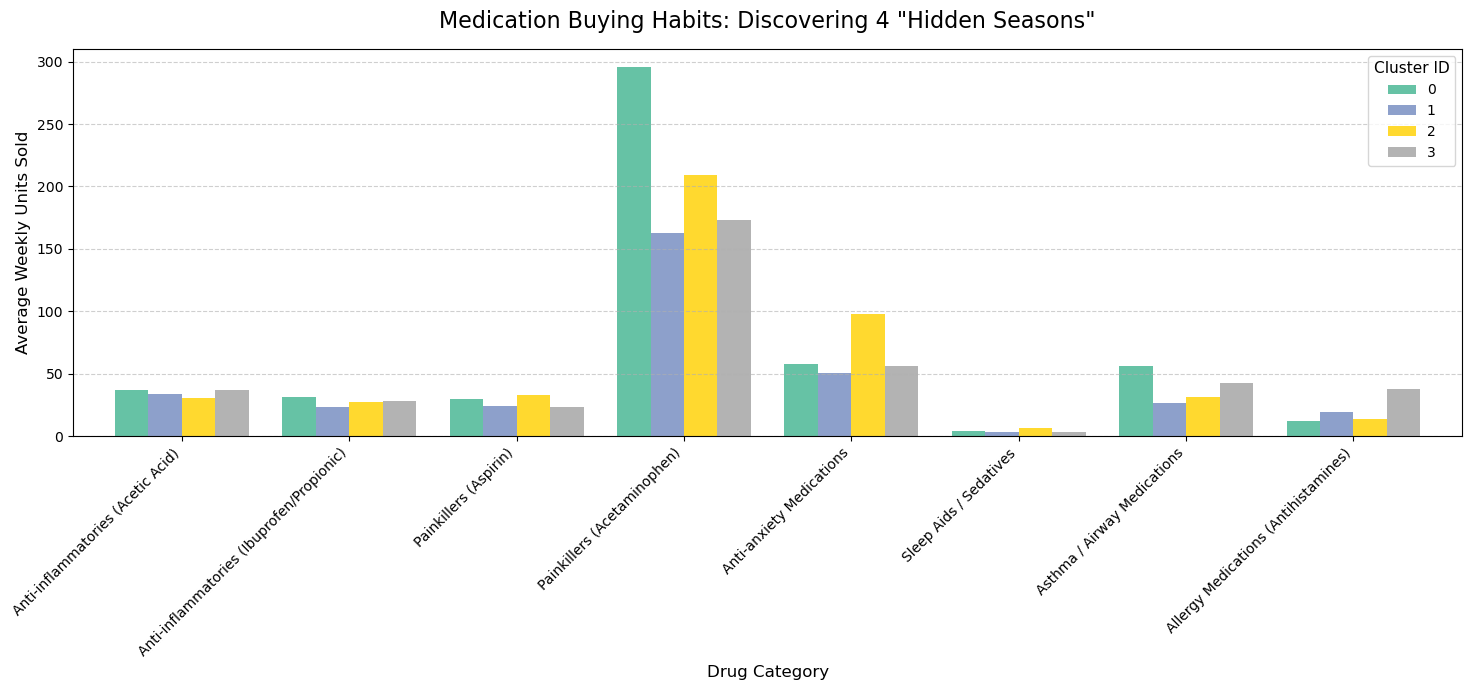

------------------------------------------------------------
CLUSTER TIMING ANALYSIS:
Cluster 0 most frequently occurs in Months: [10, 1, 2]
Cluster 1 most frequently occurs in Months: [7, 8, 4]
Cluster 2 most frequently occurs in Months: [1, 2, 8]
Cluster 3 most frequently occurs in Months: [5, 4, 6]
------------------------------------------------------------


In [38]:
print("Preparing data for K-Means Clustering...")

cluster_data = weekly_data.copy()

# 2. Scale the data (CRITICAL for K-Means accuracy)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# 3. Train the K-Means model (Create 4 "Seasons")
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_data['Cluster'] = kmeans.fit_predict(scaled_data)

# 4. Analyze the Clusters (Calculate average sales per drug for each cluster)
cluster_profiles = cluster_data.groupby('Cluster').mean()

# 5. Visualize the "Hidden Seasons" 
cluster_profiles.T.plot(kind='bar', figsize=(15, 7), width=0.8, colormap='Set2')
plt.title('Medication Buying Habits: Discovering 4 "Hidden Seasons"', fontsize=16, pad=15)
plt.xlabel('Drug Category', fontsize=12)
plt.ylabel('Average Weekly Units Sold', fontsize=12)
plt.legend(title='Cluster ID', title_fontsize='11', fontsize='10')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('kmeans_hidden_seasons.png')
plt.show()

# 6. Prove the "Seasonality" by checking which months dominate each cluster
cluster_data['Month'] = cluster_data.index.month
print("-" * 60)
print("CLUSTER TIMING ANALYSIS:")
for i in range(4):
    top_months = cluster_data[cluster_data['Cluster'] == i]['Month'].value_counts().head(3).index.tolist()
    print(f"Cluster {i} most frequently occurs in Months: {top_months}")
print("-" * 60)